## TP20 - Ordonnancement - Cycle 

!!! info Problème
Étude de cas : Le chantier de la "Maison Algorithmique"\
Imaginons les étapes nécessaires pour construire une maison. Chaque étape est un sommet, et une flèche $A \to B$ signifie qu'il faut avoir fini $A$ pour commencer $B$.

1. Liste des tâches
- 'Plan' : Réalisation des plans par l'architecte
- 'Permis' : Obtention du permis de construire
- 'Fondations' : Creuser les fondations
- 'Murs' : Monter les murs (Gros œuvre)
- 'Toit' : Pose de la charpente et du toit (Mise hors d'eau)
- 'Elec' : Installation électrique et plomberie
- 'Finitions' : Pose du carrelage et peinture (Finitions)
- 'Emmenagement' : Remise des clés (Emménagement)

2. Les contraintes
Voici les dépendances logiques que les élèves devront modéliser :
- Le permis nécessite les plans 
- Les fondations attendent le permis 
- Les murs reposent sur les fondations 
- Le toit nécessite les murs 
- L'électricité se fait une fois les murs montés 
- Les finitions attendent que le toit soit posé ET que l'électricité soit faite 
- On emménage quand les finitions sont prêtes 
!!!

## Exercice 1 : Ordonnancement - construction de la maison

!!! question Question 1
Implémenter le graphe décrit ci-dessus.
!!!

In [1]:
maison = {
    "Plan": ["Permis"],
    "Permis": ["Fondations"],
    "Fondations": ["Murs"],
    "Murs": ["Toit", "Elec"],
    "Toit": ["Finitions"],
    "Elec": ["Finitions"],
    "Finitions": ["Emmenagement"],
    "Emmenagement": []
}

In [98]:
import networkx as nx
import matplotlib.pyplot as plt

def afficher_graphe_liste(dico, digraphe = False):
    # Création du graphe orienté à partir du dictionnaire
    if digraphe:
        G = nx.DiGraph(dico)
    else:
        G = nx.Graph(dico)

    # Dessin
    plt.figure(figsize=(8, 6))
    nx.draw(G, with_labels=True, node_color='lightgreen', node_size=2500)
    plt.show()

In [99]:
#afficher_graphe_liste(maison, True)

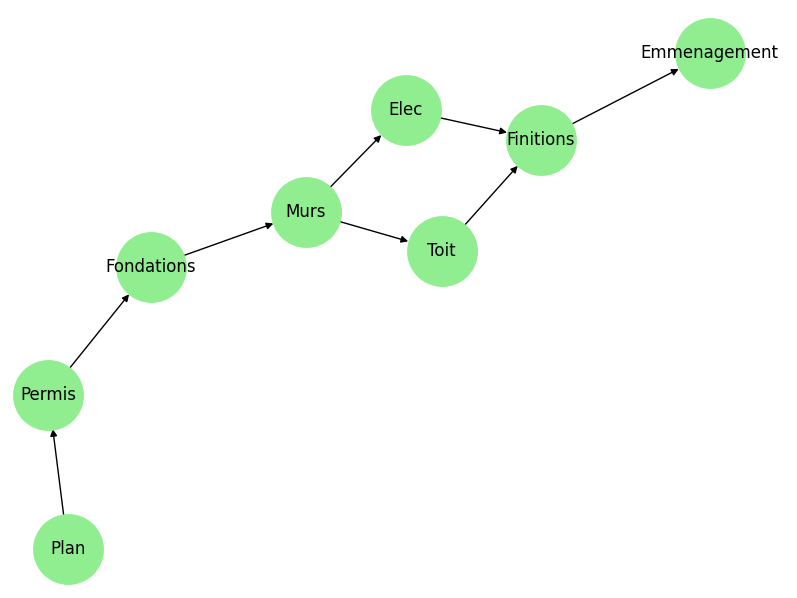

!!! question Question 2
Le parcours en profondeur utilise une pile. On peut se passer de cette structure via la récursivité. En effet les appelles récursifs sont gérés par la pile d'appel de python.

Écrire la fonction récursive `parcours_profondeur_rec_aux(g: dict, s: str, visites: set) -> list[str]` et donc la fonction `parcours_profondeur_rec(g, s)` .
!!!
!!! example Algorithme
<style>
    .aide-dfs-container {
        margin: 20px 0;
    }
    .aide-dfs-details {
        border: 2px dashed #007bff;
        border-radius: 8px;
        background-color: #f0f7ff;
        transition: all 0.3s ease;
    }
    .aide-dfs-summary {
        padding: 10px;
        font-weight: bold;
        color: #0056b3;
        cursor: pointer;
        list-style: none;
        text-align: center;
    }
    .aide-dfs-summary:hover {
        background-color: #e3f2fd;
    }
    .aide-dfs-summary:before {
        content: "⚙️ ";
    }
    .aide-dfs-content {
        padding: 15px;
        border-top: 1px solid #bbdefb;
        color: #333;
    }
    .code-logic {
        font-family: 'Courier New', Courier, monospace;
        font-weight: bold;
        color: #d81b60;
    }
    .indent {
        margin-left: 20px;
        border-left: 1px solid #ccc;
        padding-left: 10px;
    }
</style>

<div class="aide-dfs-container">
<details class="aide-dfs-details">
<summary class="aide-dfs-summary">Voir pour aide : Logique du parcours récursif</summary>
<div class="aide-dfs-content">

<span class="code-logic">parcours_profondeur_rec_aux(g, s, visites) :</span>
<div class="indent">
    • Initialiser <span class="code-logic">res</span> (liste vide)<br>
    • <b>Si</b> <span class="code-logic">s</span> n'est pas dans <span class="code-logic">visites</span> :
    <div class="indent">
        • Marquer <span class="code-logic">s</span> comme visité<br>
        • Ajouter <span class="code-logic">s</span> au résultat<br>
        • <b>Pour chaque</b> successeur de <span class="code-logic">s</span> :
        <div class="indent">
            • <b>Si</b> le successeur n'est pas visité :
            <div class="indent">
                • Étendre le résultat avec l'appel récursif sur ce voisin
            </div>
        </div>
    </div>
    • <b>Retourner</b> <span class="code-logic">res</span>
</div>

</div>
</details>
</div>
!!!

In [2]:
def parcours_profondeur_rec_aux(g, s, visites):
    res = []
    if s not in visites:
        visites.add(s)
        res.append(s)

        for successeur in g[s]:
            if successeur not in visites:
                res += parcours_profondeur_rec_aux(g, successeur, visites)
    return res

def parcours_profondeur_rec(g, s):
    return parcours_profondeur_rec_aux(g, s, set())

In [3]:
print(parcours_profondeur_rec(maison, 'Plan')) 

['Plan', 'Permis', 'Fondations', 'Murs', 'Toit', 'Finitions', 'Emmenagement', 'Elec']


In [4]:
print(parcours_profondeur_rec(maison, 'Toit')) # ['Toit', 'Finitions', 'Emmenagement']

['Toit', 'Finitions', 'Emmenagement']


!!! question Question 3
À l'aide de votre fonction `parcours_profondeur_rec_aux()`, écrire une fonction `parcours_profondeur_rec_total(g: dict) -> list[str]` qui lance un parcours en profondeur depuis chaque sommet pas encore visité pour s'assurer de couvrir tous les sommets du graphe.
!!!

In [5]:
def parcours_profondeur_rec_total(g):
    visites = set()
    res = []
    for cle in g :
        if cle not in visites:
            res += parcours_profondeur_rec_aux(g, cle, visites)
    return res

In [6]:
print(parcours_profondeur_rec_total(maison)) 

['Plan', 'Permis', 'Fondations', 'Murs', 'Toit', 'Finitions', 'Emmenagement', 'Elec']


!!! question Question 4
Est-ce que votre parcours en profondeur nous permet de trouver un ordre dans lequel effectuer les tâches sans avoir de problème lors de la construction de la maison ?
!!!

!!! info Tri topologique
Soit G un graphe orienté acyclique. Un tri topologique est une liste ordonnée de ses sommets telle
que, pour tout arc $A → B$ dans le graphe, le sommet $A$ apparait avant le sommet $B$ dans la liste.

Le tri topologique peut s'obtenir en utilisant le parcours en profondeur : un sommet est ajouté à la liste de l'ordonnancement _(résultat)_ après que tous ses successeurs ont été visités (post-ordre), puis on inverse la liste finale.
!!!
!!! question Quesiton 5
Écrire une focntion `tri_topo(g: dict, s: str) -> list[str]` qui implémente le tri topologique. \
Vous commencerez par faire une fonction `tri_topo_aux(g: dict, s: str, visites: set) -> list[str]`.

_Reprenez le code de votre tri par profondeur et modifier ce qu'il faut pour arriver au tri topologique_
!!!

In [7]:
def tri_topo_aux(g, s, visites):
    res = []
    if s not in visites:
        visites.add(s)
        for successeur in g[s]:
            if successeur not in visites:
                res += tri_topo_aux(g, successeur, visites)
        res.append(s)
    return res

def tri_topo(g, s):
    res = tri_topo_aux(g, s, set())
    return res[::-1]

In [9]:
print(tri_topo(maison, 'Plan')) #['Plan', 'Permis', 'Fondations', 'Murs', 'Elec', 'Toit', 'Finitions', 'Emmenagement']

['Plan', 'Permis', 'Fondations', 'Murs', 'Elec', 'Toit', 'Finitions', 'Emmenagement']


!!! question Question 6
La mairie refuse de valider le Permis de construire tant que vous n'avez pas prouvé que vous avez déjà emménagé pour payer la taxe d'habitation.

Rajouter l'arc nécessaire à votre graphe.
!!!

In [10]:
maison['Emmenagement'] = ["Permis"]

!!! question Question 7
Est-il possible d'avoir un tri topologique sur notre graphe ? Pourquoi ? 

Que renvoie votre fonction tri_topologique ?
!!!

In [12]:
print(tri_topo(maison, 'Plan'))

['Plan', 'Permis', 'Fondations', 'Murs', 'Elec', 'Toit', 'Finitions', 'Emmenagement']


## Exercice 2 : Détection de cycles - Aglo 3 couleurs


!!! info 
Dans un graphe orienté, le simple marquage "visité / non-visité" ne suffit pas. Si vous tombez sur un sommet déjà visité, cela ne signifie pas forcément qu'il y a un cycle (cela peut être une "arête transverse" ou une "arête avant"). Pour être sûr qu'il y a un cycle, il faut tomber sur un sommet qui est encore dans la pile d'exécution du parcours actuel.
!!!

!!! example Algorithme 3 couleurs 

Voici le détail de la méthode des trois couleurs :
1. La signification des couleurs :
    + Blanc : Sommet "Inconnu". On n'est jamais passé par ici.
    + Gris : Sommet "En cours". On est entré dans l'appel récursif, mais on n'en est pas encore sorti. Le sommet est actuellement dans la pile d'appels.
    + Noir : Sommet "Terminé". On a fini d'explorer tous ses voisins et tous ses descendants. On est sorti de l'appel récursif.

2. Le mécanisme de détection : 
    + Un cycle existe si et seulement si on tente de visiter un sommet Gris.
    + Pourquoi ? Parce que si le sommet $v$ est gris, cela veut dire qu'il est un ancêtre du sommet $u$ actuellement exploré. Si on trouve une arête $(u, v)$, on ferme une boucle qui remonte vers un ancêtre : c'est une arête de retour.
!!!


<style>
    /* Style pour les blocs escamotables */
    details {
        border: 1px solid #aaa;
        border-radius: 4px;
        padding: 0.5em 0.5em 0;
        margin-bottom: 10px;
        background-color: #f9f9f9;
        transition: all 0.3s ease;
    }

    summary {
        font-weight: bold;
        margin: -0.5em -0.5em 0;
        padding: 0.5em;
        cursor: pointer;
        list-style: none; /* Cache la flèche par défaut sur certains navigateurs */
    }

    summary:before {
        content: "▶️ "; /* Ajoute une icône explicite */
        font-size: 0.8em;
    }

    details[open] summary:before {
        content: "🔽 "; /* Change l'icône quand c'est ouvert */
    }

    summary:hover {
        background-color: #e2e2e2;
        color: #0056b3;
    }

    details[open] {
        padding: 0.5em;
        background-color: #fff;
        border-left: 5px solid #007bff;
    }

    .step-img-container {
        text-align: center;
        padding: 10px;
    }
</style>

## Visualisation pas à pas, avec cycle

*Cliquez sur chaque étape ci-dessous pour dérouler l'explication et l'image associée.*

<details>
<summary>Étape 1 : Départ de A</summary>
<div class="step-img-container">
    <p>Le sommet <b>A</b> est marqué en <span style="color: grey;">Gris</span> (entrée dans la pile).</p>
       <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-depuis-A-_-etape-2-1.png" width="400">

</div>
</details>

<details>
<summary>Étape 2 : Visite de B</summary>
<div class="step-img-container">
    <p>On suit l'arête <b>A → B</b>. Le sommet <b>B</b> devient <span style="color: grey;">Gris</span>.</p>
        <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-depuis-A-_-etape-3-1.png" width="400">

</div>
</details>

<details>
<summary>Étape 3 : Visite de C</summary>
<div class="step-img-container">
    <p>On suit l'arête <b>B → C</b>. Le sommet <b>C</b> devient <span style="color: grey;">Gris</span>.</p>
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-depuis-A-_-etape-4-1.png" width="400">
</div>
</details>

<details>
<summary>Étape 4 : Visite de E</summary>
<div class="step-img-container">
    <p>On suit l'arête <b>C → E</b>. Le sommet <b>E</b> devient <span style="color: grey;">Gris</span>.</p>
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-depuis-A-_-etape-5-1.png" width="400">
</div>
</details>

<details>
<summary>Étape 5 : Détection du cycle !</summary>
<div class="step-img-container">
    <p style="color: #d9534f; font-weight: bold;">⚠️ Alerte Cycle</p>
    <p>Depuis <b>C</b>, on voit une arête vers <b>B</b>. Or, <b>B est déjà Gris</b> (il est toujours dans la pile d'appels). C'est une <b>arête de retour</b>.</p>
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-depuis-A-_-etape-6-2.png" width="400">
</div>
</details>

## Visualisation pas à pas, sans cycle

*Cliquez sur chaque étape ci-dessous pour dérouler l'explication et l'image associée.*

<details>
<summary>Étape 1 : Départ de D</summary>
<div class="step-img-container">
   <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-1-3.png" width="400">

</div>
</details>

<details>
<summary>Étape 2 : Visite de E</summary>
<div class="step-img-container">
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-2-1.png" width="400">
</div>
</details>

<details>
<summary>Étape 3 : Visite de B</summary>
<div class="step-img-container">
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-3-2.png" width="400">
</div>
</details>

<details>
<summary>Étape 4 : Visite de C</summary>
<div class="step-img-container">
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-4.png" width="400">
</div>
</details>

<details>
<summary>Étape 5 : Visite de F</summary>
<div class="step-img-container">
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-5.png" width="400">
</div>
</details>

<details>
<summary>Étape 6 : F en noir</summary>
<div class="step-img-container">
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-6.png" width="400">
</div>
</details>

<details>
<summary>Étape 7 : C en noir</summary>
<div class="step-img-container">
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-7.png" width="400">
</div>
</details>

<details>
<summary>Étape 8 : B en noir</summary>
<div class="step-img-container">
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-8.png" width="400">
</div>
</details>

<details>
<summary>Étape 9 : E en noir</summary>
<div class="step-img-container">
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-9.png" width="400">
</div>
</details>

<details>
<summary>Étape 10 : D en noir : pas de cycle depuis D</summary>
<div class="step-img-container">
    <img src="https://info.blaisepascal.fr/wp-content/uploads/2021/01/cycle-10-1.png" width="400">
</div>
</details>





!!! question Question 1
Écrire une fonction `contient_cycle_s(g, s) -> bool` qui effectue l'algorithme décris ci-dessus. Depuis un sommet de départ.\
Vous passerez par une fonction auxiliaire `couleurs_3(g, s, couleurs: dict) -> bool` dans laquelle couleurs est un dictionnaire qui associe à chaque sommet une couleur.

_Vous pouvez repartir de votre code du parcours en profondeur_
!!!

<style>
    .aide-3couleurs-container {
        margin: 20px 0;
    }
    .aide-3couleurs-details {
        border: 2px dashed #4caf50;
        border-radius: 8px;
        background-color: #e8f5e9;
        transition: all 0.3s ease;
    }
    .aide-3couleurs-summary {
        padding: 10px;
        font-weight: bold;
        color: #2e7d32;
        cursor: pointer;
        list-style: none;
        text-align: center;
    }
    .aide-3couleurs-summary:hover { background-color: #c8e6c9; }
    .aide-3couleurs-summary:before { content: "🎨 "; }

    .aide-3couleurs-content {
        padding: 15px;
        border-top: 1px solid #a5d6a7;
        color: #333;
    }

    .code-logic {
        font-family: 'Courier New', Courier, monospace;
        font-weight: bold;
        color: #d81b60;
    }
    .indent {
        margin-left: 20px;
        border-left: 1px solid #ccc;
        padding-left: 10px;
    }
</style>
<div class="aide-3couleurs-container">
<details class="aide-3couleurs-details">
<summary class="aide-3couleurs-summary">Voir pour aide : Algorithme des 3 couleurs (Détection de cycle)</summary>
<div class="aide-3couleurs-content">

<span class="code-logic">Explorer(sommet) :</span>
<div class="indent">
    • <b>Si</b> <span class="code-logic">sommet</span> est <span style="color: grey;">Gris</span> : <b>Retourner</b> <span class="code-logic">Vrai</span> (Cycle détecté)<br>
    • <b>Si</b> <span class="code-logic">sommet</span> est <span style="color: black;">Noir</span> : <b>Retourner</b> <span class="code-logic">Faux</span><br>
    • Marquer <span class="code-logic">sommet</span> en <span style="color: grey;">Gris</span><br>
    • <b>Pour chaque</b> <span class="code-logic">voisin</span> de <span class="code-logic">sommet</span> :<br>
    <div class="indent">
        • <b>Si</b> <span class="code-logic">Explorer(voisin)</span> est <span class="code-logic">Vrai</span> : <b>Retourner</b> <span class="code-logic">Vrai</span>
    </div>
    • Marquer <span class="code-logic">sommet</span> en <span style="color: black;">Noir</span><br>
    • <b>Retourner</b> <span class="code-logic">Faux</span>
</div>

</div>
</details>
</div>


In [13]:
def couleurs_3(g, s, couleurs):
    # si Blanc : nouvelle branche, on visite
    if couleurs[s] == 'Blanc':
        couleurs[s] = 'Gris'
        
        # on continue à parcourir en profondeur
        for successeur in g[s]:
            if couleurs_3(g, successeur, couleurs):
                return True
        # une fois tout les voisins visités, on marque en noir
        couleurs[s] = 'Noir'
        return False
    else :
        return couleurs[s] == 'Gris'


def contient_cycle_s(g, s):
    # initialisation des couleurs en Blanc
    couleurs = {}
    for cle in g:
        couleurs[cle] = 'Blanc'
    
    return couleurs_3(g, s, couleurs)


In [14]:
# avec la maison sans cycle :
maison = {
    "Plan": ["Permis"],
    "Permis": ["Fondations"],
    "Fondations": ["Murs"],
    "Murs": ["Toit", "Elec"],
    "Toit": ["Finitions"],
    "Elec": ["Finitions"],
    "Finitions": ["Emmenagement"],
    "Emmenagement": []
}
print(contient_cycle_s(maison, 'Plan')) # False

False


In [16]:
# on rajoute un cycle :
maison['Emmenagement'] = ["Permis"]
print(contient_cycle_s(maison, 'Plan')) # True

True


!!! question Question 2
Écrire une fonction `contient_cycle(g)` qui regarde pour chaque sommet si il fait parti d'un cycle.
!!!

In [17]:
def contient_cycle(g):
    for cle in g:
        if contient_cycle_s(g, cle):
            return True
    return False

In [18]:
maison = {
    "Plan": ["Permis"],
    "Permis": ["Fondations"],
    "Fondations": ["Murs"],
    "Murs": ["Toit", "Elec"],
    "Toit": ["Finitions"],
    "Elec": ["Finitions"],
    "Finitions": ["Emmenagement"],
    "Emmenagement": []
}
print(contient_cycle(maison)) # False

False


In [19]:
maison['Emmenagement'] = ["Permis"]
print(contient_cycle(maison)) # True

True
